<a href="https://colab.research.google.com/github/AncaraniJuanDiego/AnlisisSeriesTemporales/blob/main/TP_ST_PruebasEstKpss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Operador de retraso, diferenciación y prueba x kpss

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import kpss
import warnings


# Ignorar advertencias para una salida más limpia en clase
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
#Cargar datos

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
series = df['Passengers']
series.name = 'Pasajeros'

print("--- Análisis de la Serie Original ---")
print(series.head(10))
print("\n")

--- Análisis de la Serie Original ---
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
Name: Pasajeros, dtype: int64




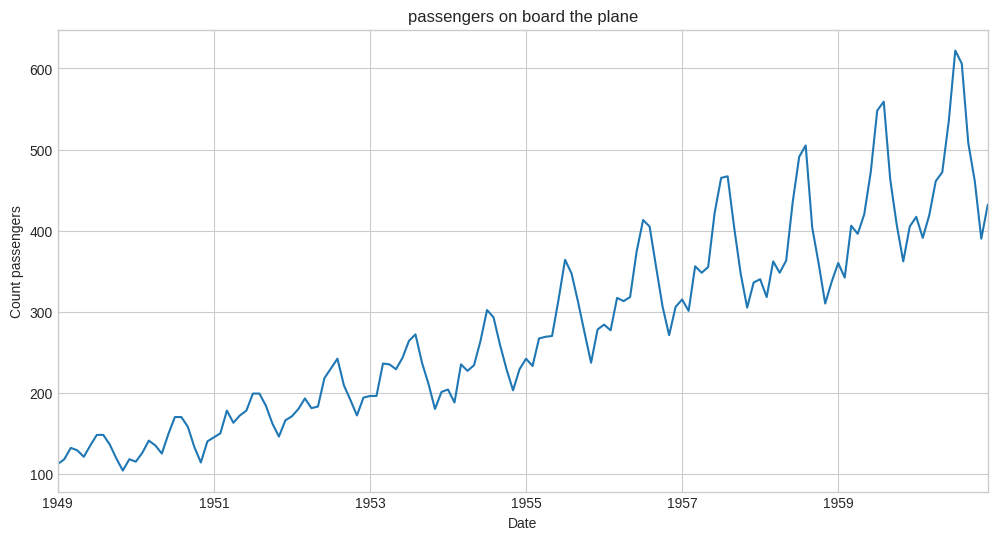

In [ ]:
#Visualizar serie

series.plot(title = 'passengers on board the plane')
plt.xlabel('Date')
plt.ylabel('Count passengers')
plt.show()



* Tendencia→ realmentela serie fue creciendo a lo largo de los años, con el paso del tiempo hubo más gente que empezó a tomar la línea de este avión. Pasando de Aprox 100 a + 600 frecuentemente, en 20 años.

* Estacionalidad → parece haber una época del año, en específico es común que más pasajeros tomen el vuelo. Al igual que la alta, tambien hay bajadas (no masivas) en un periodo determinado.


In [ ]:
#Tipo de prueba : x kpss

#hipotesis nula = la serie SI es estacionaria. (contrario a ADF)

def kpss_test(test_statistic, p_value, crit_values, sig_level=0.05):
    """Función para interpretar los resultados de la prueba KPSS."""

    print(f'KPSS stadistic: {test_statistic:.4f}')
    print(f'P-value: {p_value:.4f}')
    print('Critic values:')
    for key, value in crit_values.items():
        print(f'   {key}% : {value:.4f}')

    print(f'\nSignification level: {sig_level}')
    if p_value < sig_level:
        print('----Result: discard the null hypothesis (H₀)---')
        print("----Conclusion: The series isn't stationarity---")
    else:
        print('Result: Don´t discard the null hypothesis (H₀).')
        print('Conclusion: the series is stationarity.')
    print("-" * 50)

print('test by KPSS')

kpss_result = kpss(series)
kpss_test(kpss_result[0], kpss_result[1], kpss_result[3])

test by KPSS
KPSS stadistic: 1.6513
P-value: 0.0100
Critic values:
   10%% : 0.3470
   5%% : 0.4630
   2.5%% : 0.5740
   1%% : 0.7390

Signification level: 0.05
Result: discard the null hypothesis (H₀).
Conclusion: The series isn't stationarity.
--------------------------------------------------


---Demostrate retard operator---- 
            Original  Retard (B*y_t)
Month                               
1949-01-01       112             NaN
1949-02-01       118           112.0
1949-03-01       132           118.0
1949-04-01       129           132.0
1949-05-01       121           129.0

--- differentiated series analysis ---
Month
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
Name: Pasajeros, dtype: float64


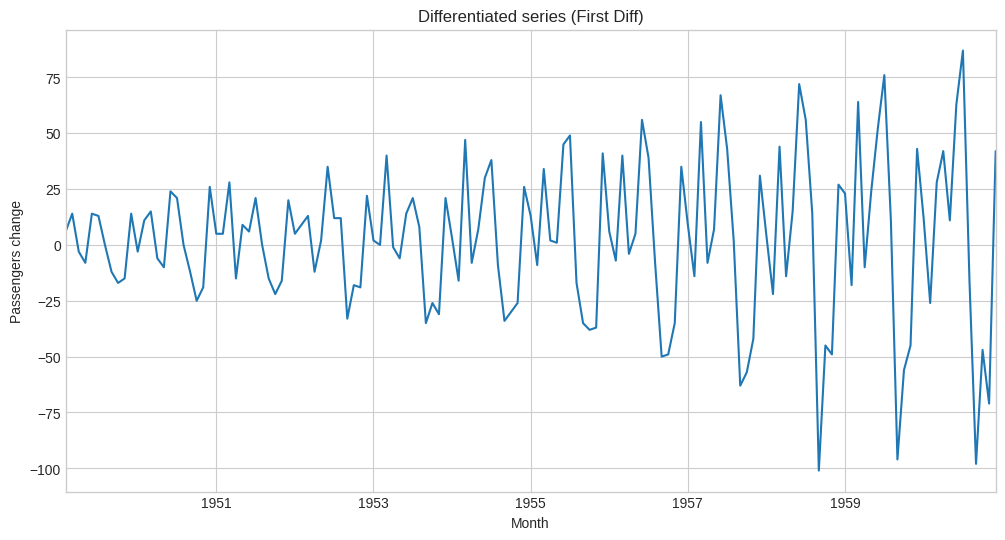

In [ ]:
#Operador de retraso

series_lag = series.shift(1)
df_lag = pd.DataFrame({'Original': series, 'Retard (B*y_t)': series_lag})
print('---Demostrate retard operator---- ')
print(df_lag.head())

#Diferenciar.

series_diff = series.diff().dropna()
print("\n--- differentiated series analysis ---")
print(series_diff.head())

# Visualización de la serie diferenciada.
series_diff.plot(title='Differentiated series (First Diff)')
plt.ylabel('Passengers change')
plt.show()

* Al principio la diferencia de pasajeros a bordo no era tan extensa, con montos de quizás [-25,25]. Con el paso de los años, empezó a crecer el volumen de pasajeros a bordo y las diferencias día tras día empezaron a crecer. Con diferencias a grandes escalas [-100-75]. De todas formas, hemos convertido la serie en estacionaria.

In [ ]:
# -Aplicar la Prueba KPSS a la Serie Diferenciada ---

kpss_stat_diff, p_value_diff, lags_diff, crit_values_diff = kpss(series_diff, regression='c')
kpss_test(kpss_stat_diff, p_value_diff, crit_values_diff)

print('Serie convertida a ESTACIONARIA correctamente.')

KPSS stadistic: 0.0239
P-value: 0.1000
Critic values:
   10%% : 0.3470
   5%% : 0.4630
   2.5%% : 0.5740
   1%% : 0.7390

Signification level: 0.05
Result: Don´t discard the null hypothesis (H₀).
Conclusion: the series is stationarity.
--------------------------------------------------
Serie convertida a ESTACIONARIA correctamente.


Prueba de heterocedasticidad: prueba de varianza constante de errores

* Errores: (valores reales - predichos) → se utilizan para visualizar que tanto el modelo 'se equivoca'


In [ ]:
import statsmodels.api as sm

                            OLS Regression Results                            
Dep. Variable:             Passengers   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     828.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           4.02e-61
Time:                        21:58:28   Log-Likelihood:                -754.82
No. Observations:                 144   AIC:                             1514.
Df Residuals:                     142   BIC:                             1520.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.3100      7.636     11.826      0.0

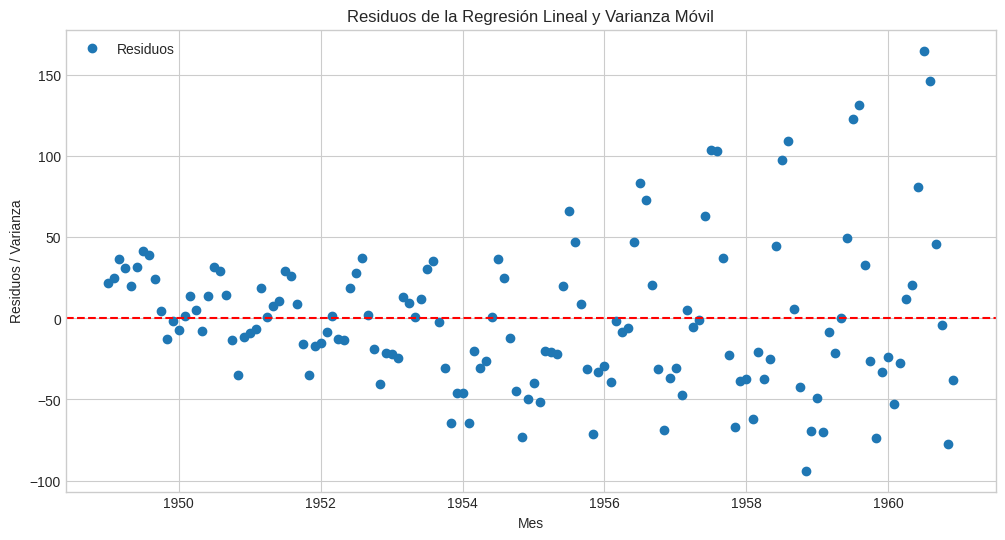

In [ ]:

X = sm.add_constant(df['Time'])  # añadir intercepto
y = df['Passengers']

model = sm.OLS(y, X).fit()
print(model.summary())  # ver resumen del modelo

# 3. Calcular residuos
residuals = model.resid

# 4. Gráfico de residuos vs. tiempo (inspección visual)
plt.figure(figsize=(12, 6))
plt.plot(df.index, residuals, 'o', label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals in the linear regression and movil variance')
plt.xlabel("Month")
plt.ylabel("Residuals distribution")
plt.grid(True)
plt.legend()
plt.show()

En este gráfico observamos la presencia de residuos frente al comportamiento de la varianza ~ 0, al principio hay un patrón significativo, donde el modelo no obtiene resultados tan erróneos, aunque mientras más avanza el tiempo, se le dificulta. de todas formas, se logra presenciar heterocedasticidad debido a la tendencia creciente de la serie y cambios de dispersión.

In [ ]:
#Vamos a probar heterocedasticidad con diferentes herramientas..
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import het_goldfeldquandt

#1. Prueba de Breusch-Pagan:  <0.05 la varianza es constante.

lm, p_value, _, _ = het_breuschpagan(residuals, X)
print(f"\nTest by Breusch-Pagan:")
print(f"LM: {lm:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nRechazamos H0: Hay evidencia de heterocedasticidad (varianza no constante)")
else:
    print("\nNo rechazamos H0: No hay evidencia de heterocedasticidad (varianza constante)")

#2. test de White:

white_test = het_white(residuals, X)
print(f"\nPrueba de White:")
print(f"Estadística LM: {white_test[0]:.4f}")
print(f"p-valor: {white_test[1]:.4f}")

if white_test[1] < 0.05:
    print("Rechazamos H0: Hay evidencia de heterocedasticidad (varianza no constante)")
else:
    print("No rechazamos H0: No hay evidencia de heterocedasticidad (varianza constante)")



#Test ARCH (Engle)
arch_result = het_arch(residuals)

print(f"\nPrueba ARCH (Engle):")
print(f"Estadística de la prueba: {arch_result[0]:.4f}")
print(f"p-valor: {arch_result[1]:.4f}")

if arch_result[1] < 0.05:
    print("Rechazamos H0: Hay evidencia de heterocedasticidad (Prueba ARCH)")
else:
    print("No rechazamos H0: No hay evidencia de efectos ARCH (heterocedasticidad condicional)")

#Test goldfeld-quandt

arch_result = het_goldfeldquandt(residuals, X)

print(f"\nPrueba usando goldfeld-quandt:")
print(f"Estadística de la prueba: {arch_result[0]:.4f}")
print(f"p-valor: {arch_result[1]:.4f}")

if arch_result[1] < 0.05:
    print("Rechazamos H0: Hay evidencia de heterocedasticidad (Prueba goldfeld-quandt) ")
else:
    print("No rechazamos H0: No hay evidencia de efectos ARCH (heterocedasticidad condicional)")



Prueba de Breusch-Pagan:
Estadística LM: 25.4419
p-valor: 0.0000

Rechazamos H0: Hay evidencia de heterocedasticidad (varianza no constante)

Prueba de White:
Estadística LM: 29.2978
p-valor: 0.0000
Rechazamos H0: Hay evidencia de heterocedasticidad (varianza no constante)

Prueba ARCH (Engle):
Estadística de la prueba: 83.6088
p-valor: 0.0000
Rechazamos H0: Hay evidencia de heterocedasticidad (Prueba ARCH)

Prueba usando goldfeld-quandt:
Estadística de la prueba: 6.1784
p-valor: 0.0000
Rechazamos H0: Hay evidencia de heterocedasticidad (Prueba goldfeld-quandt) 


Se aplicaron los tests de Breusch-Pagan, White, ARCH y Goldfeld-Quandt para evaluar la homocedasticidad de los residuos.
En todos los casos, los p-values resultaron menores a 0.05, lo que indica la presencia de heterocedasticidad.
Esto sugiere que la varianza de los errores no es constante en el tiempo DEFINITIVAMENTE.